# 🏥 Phase 2: Deep Learning — Medical Image Diagnosis
## Supervised Learning — Spring 2026

---
**Pipeline:**
1. Mount Google Drive & Imports
2. Load Data (3000 images — YOUR dataset)
3. CNN from Scratch + Architecture Diagram + Training Curves
4. Autoencoder + Anomaly Detection
5. Transfer Learning: VGG16 / MobileNetV2 / ResNet50 / EfficientNetB0
6. Optimizer Comparison: Adam vs SGD vs RMSprop
7. Final Comparison Table
---

## 📦 Cell 1: Mount Google Drive

In [1]:
try:
    from google.colab import drive
    drive.mount('/content/drive')
    print('✅ Google Drive mounted!')
except Exception:
    print('Not running in Colab; skipping Drive mount.')

Not running in Colab; skipping Drive mount.


## 📦 Cell 2: Imports & GPU Check

In [2]:
import os, warnings, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch
import seaborn as sns
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_curve, auc, ConfusionMatrixDisplay,
                             accuracy_score, f1_score)
from sklearn.utils.class_weight import compute_class_weight
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, callbacks
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16, MobileNetV2, ResNet50, EfficientNetB0
warnings.filterwarnings('ignore')
np.random.seed(42); tf.random.set_seed(42); random.seed(42)
print(f'TensorFlow   : {tf.__version__}')
print(f'GPU Available: {bool(tf.config.list_physical_devices("GPU"))}')
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print(f'GPU Name: {gpus[0].name}')
else:
    print('No GPU — Go to Runtime > Change runtime type > T4 GPU')

TensorFlow   : 2.20.0
GPU Available: False
No GPU — Go to Runtime > Change runtime type > T4 GPU


## ⚙️ Cell 3: Configuration

In [3]:
def guess_base_dir():
    if os.path.exists("/content/drive/MyDrive"):
        return "/content/drive/MyDrive/Medical_Project"
    return os.path.abspath(os.path.join(os.getcwd(), "..", "data"))

BASE_DIR   = os.environ.get("MEDICAL_DATA_DIR", guess_base_dir())
IMAGES_DIR = os.path.join(BASE_DIR, "sample", "images")
CSV_PATH   = os.path.join(BASE_DIR, "sample_labels.csv")
IMG_SIZE     = 128
CHANNELS     = 1
BATCH_SIZE   = 32
EPOCHS_CNN   = 25
EPOCHS_AE    = 20
EPOCHS_TL    = 8
EPOCHS_OPT   = 8
SAMPLE_SIZE  = 3000
VAL_SPLIT    = 0.15
TEST_SPLIT   = 0.15
NORMAL_LABEL = 'No Finding'
RANDOM_SEED  = 42
print(f'Images dir : {IMAGES_DIR}')
print(f'CSV path   : {CSV_PATH}')

Images dir : c:\Users\Omar Awad\Downloads\SupervisedLearningProject\data\sample\images
CSV path   : c:\Users\Omar Awad\Downloads\SupervisedLearningProject\data\sample_labels.csv


## 📂 Cell 4: Load & Prepare Data

In [4]:
df = pd.read_csv(CSV_PATH)
print(f'Columns: {df.columns.tolist()}')
df['img_path'] = df['Image Index'].apply(lambda x: os.path.join(IMAGES_DIR, x))
df = df[df['img_path'].apply(os.path.exists)].reset_index(drop=True)
print(f'Images on disk: {len(df):,}')
if 'Finding Labels' in df.columns:
    df['label'] = (df['Finding Labels'].apply(lambda x: x.split('|')[0]) != NORMAL_LABEL).astype(int)
else:
    df['label'] = (df[df.columns[1]] != NORMAL_LABEL).astype(int)
print(df['label'].value_counts().rename({0:'Normal (0)', 1:'Diseased (1)'}))

Columns: ['Image Index', 'Finding Labels', 'Follow-up #', 'Patient ID', 'Patient Age', 'Patient Gender', 'View Position', 'OriginalImageWidth', 'OriginalImageHeight', 'OriginalImagePixelSpacing_x', 'OriginalImagePixelSpacing_y']
Images on disk: 5,606
label
Normal (0)      3044
Diseased (1)    2562
Name: count, dtype: int64


In [5]:
if SAMPLE_SIZE < len(df):
    df, _ = train_test_split(df, train_size=SAMPLE_SIZE, stratify=df['label'], random_state=RANDOM_SEED)
    df = df.reset_index(drop=True)
train_df, test_df = train_test_split(df, test_size=TEST_SPLIT, stratify=df['label'], random_state=RANDOM_SEED)
train_df, val_df  = train_test_split(train_df, test_size=VAL_SPLIT/(1-TEST_SPLIT),
                                     stratify=train_df['label'], random_state=RANDOM_SEED)
print(f'Train:{len(train_df):,} | Val:{len(val_df):,} | Test:{len(test_df):,}')

Train:2,099 | Val:451 | Test:450


## 🖼️ Cell 5: Load Images into Memory

Loading train...
Loading val  ...
Loading test ...
X_train:(2099, 128, 128, 1) | X_val:(451, 128, 128, 1) | X_test:(450, 128, 128, 1)


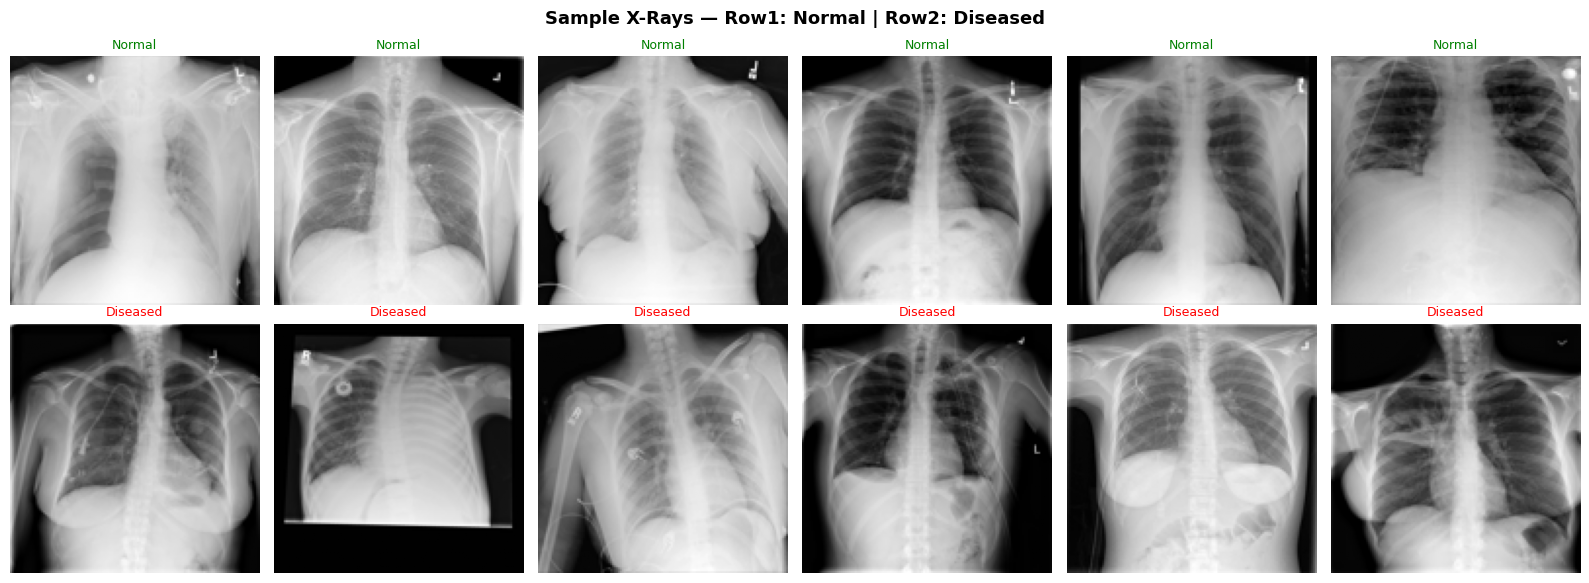

In [6]:
def load_images(dataframe, img_size, channels=1):
    X, y = [], []
    for _, row in dataframe.iterrows():
        try:
            mode = 'L' if channels == 1 else 'RGB'
            img  = Image.open(row['img_path']).convert(mode).resize((img_size, img_size))
            arr  = np.array(img, dtype=np.float32) / 255.0
            if channels == 1: arr = arr[..., np.newaxis]
            X.append(arr); y.append(row['label'])
        except: pass
    return np.array(X), np.array(y)

print('Loading train...'); X_train, y_train = load_images(train_df, IMG_SIZE, CHANNELS)
print('Loading val  ...'); X_val,   y_val   = load_images(val_df,   IMG_SIZE, CHANNELS)
print('Loading test ...'); X_test,  y_test  = load_images(test_df,  IMG_SIZE, CHANNELS)
print(f'X_train:{X_train.shape} | X_val:{X_val.shape} | X_test:{X_test.shape}')

fig, axes = plt.subplots(2, 6, figsize=(16, 6))
fig.suptitle('Sample X-Rays — Row1: Normal | Row2: Diseased', fontsize=13, fontweight='bold')
normals = np.where(y_train==0)[0][:6]; diseased = np.where(y_train==1)[0][:6]
for col,(ni,di) in enumerate(zip(normals,diseased)):
    axes[0,col].imshow(X_train[ni,...,0], cmap='gray'); axes[0,col].axis('off')
    axes[0,col].set_title('Normal', fontsize=9, color='green')
    axes[1,col].imshow(X_train[di,...,0], cmap='gray'); axes[1,col].axis('off')
    axes[1,col].set_title('Diseased', fontsize=9, color='red')
plt.tight_layout(); plt.show()

## 🧠 Cell 6: Build CNN from Scratch

In [7]:
def build_cnn(input_shape=(IMG_SIZE, IMG_SIZE, CHANNELS)):
    inp = layers.Input(shape=input_shape, name='Input')
    x = layers.Conv2D(32,  3, padding='same', name='Conv1')(inp)
    x = layers.BatchNormalization()(x); x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D(2, name='Pool1')(x)
    x = layers.Conv2D(64,  3, padding='same', name='Conv2')(x)
    x = layers.BatchNormalization()(x); x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D(2, name='Pool2')(x)
    x = layers.Conv2D(128, 3, padding='same', name='Conv3')(x)
    x = layers.BatchNormalization()(x); x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D(2, name='Pool3')(x)
    x = layers.Conv2D(256, 3, padding='same', name='Conv4')(x)
    x = layers.BatchNormalization()(x); x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D(2, name='Pool4')(x)
    x   = layers.GlobalAveragePooling2D(name='GAP')(x)
    x   = layers.Dense(256, activation='relu', name='FC')(x)
    x   = layers.Dropout(0.5)(x)
    out = layers.Dense(1, activation='sigmoid', name='Output')(x)
    return models.Model(inp, out, name='ChestXray_CNN')

cnn_model = build_cnn()
cnn_model.summary()

Model: "ChestXray_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Input (InputLayer)              │ (None, 128, 128, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv1 (Conv2D)                  │ (None, 128, 128, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Pool1 (MaxPooling2D)            │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv2 (Conv2D)                  │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Pool2 (MaxPooling2D)            │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv3 (Conv2D)                  │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Pool3 (MaxPooling2D)            │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv4 (Conv2D)                  │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Pool4 (MaxPooling2D)            │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ GAP (GlobalAveragePooling2D)    │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ FC (Dense)                      │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output (Dense)                  │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 455,809 (1.74 MB)

 Trainable params: 454,849 (1.74 MB)

 Non-trainable params: 960 (3.75 KB)

## 🧠 Cell 7: CNN Architecture Diagram

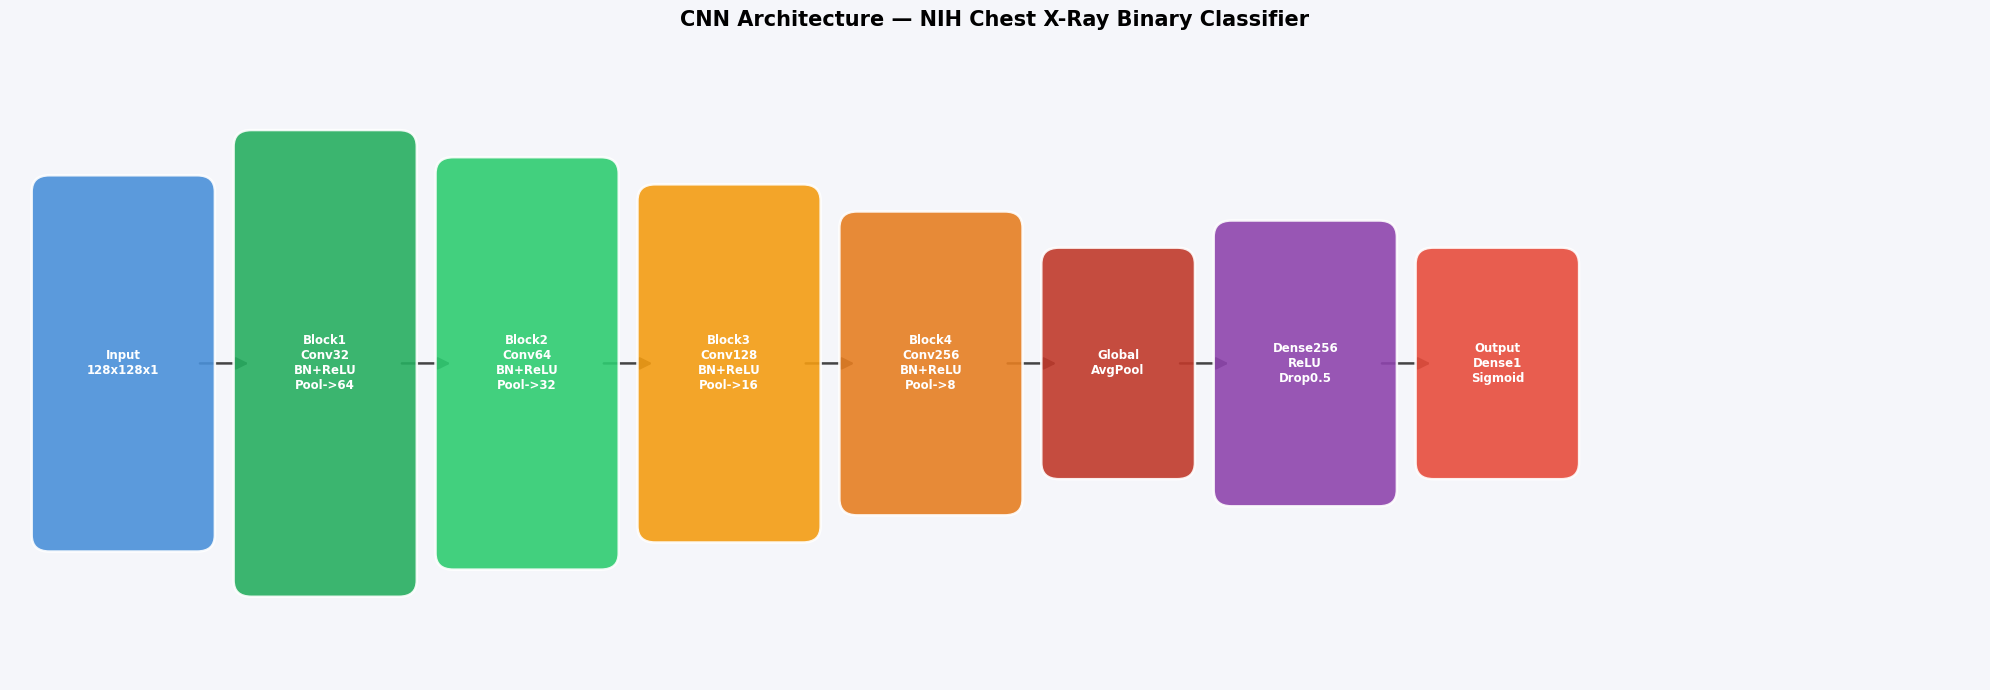

Saved -> cnn_architecture_diagram.png


In [8]:
def draw_cnn_architecture():
    fig, ax = plt.subplots(figsize=(20, 7))
    ax.set_xlim(0, 20); ax.set_ylim(0, 7); ax.axis('off')
    ax.set_facecolor('#F5F6FA'); fig.patch.set_facecolor('#F5F6FA')
    blocks = [
        ('Input\n128x128x1', 1.5, 3.8, '#4A90D9'),
        ('Block1\nConv32\nBN+ReLU\nPool->64', 1.5, 4.8, '#27AE60'),
        ('Block2\nConv64\nBN+ReLU\nPool->32', 1.5, 4.2, '#2ECC71'),
        ('Block3\nConv128\nBN+ReLU\nPool->16', 1.5, 3.6, '#F39C12'),
        ('Block4\nConv256\nBN+ReLU\nPool->8',  1.5, 3.0, '#E67E22'),
        ('Global\nAvgPool', 1.2, 2.2, '#C0392B'),
        ('Dense256\nReLU\nDrop0.5', 1.5, 2.8, '#8E44AD'),
        ('Output\nDense1\nSigmoid', 1.3, 2.2, '#E74C3C'),
    ]
    x_cur = 0.4; xs = []
    for label, w, h, color in blocks:
        y_bot = (7-h)/2
        rect = FancyBboxPatch((x_cur, y_bot), w, h, boxstyle='round,pad=0.18',
                              linewidth=1.8, edgecolor='white', facecolor=color, alpha=0.9, zorder=3)
        ax.add_patch(rect)
        ax.text(x_cur+w/2, y_bot+h/2, label, ha='center', va='center',
                fontsize=8.5, color='white', fontweight='bold', zorder=4, multialignment='center')
        xs.append((x_cur, x_cur+w)); x_cur += w+0.55
    for i in range(len(xs)-1):
        ax.annotate('', xy=(xs[i+1][0], 3.5), xytext=(xs[i][1], 3.5),
                    arrowprops=dict(arrowstyle='-|>', color='#444', lw=1.8, mutation_scale=18), zorder=2)
    ax.set_title('CNN Architecture — NIH Chest X-Ray Binary Classifier', fontsize=15, fontweight='bold', pad=15)
    plt.tight_layout(); plt.savefig('cnn_architecture_diagram.png', dpi=180, bbox_inches='tight')
    plt.show(); print('Saved -> cnn_architecture_diagram.png')
draw_cnn_architecture()

## 🧠 Cell 8: Train CNN

In [9]:
cw_vals = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = dict(enumerate(cw_vals))
print('Class weights:', {k: round(v,3) for k,v in class_weight_dict.items()})
train_aug = ImageDataGenerator(rotation_range=8, width_shift_range=0.05,
                               height_shift_range=0.05, horizontal_flip=True, zoom_range=0.08)
cnn_model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc'),
             tf.keras.metrics.Precision(name='precision'),
             tf.keras.metrics.Recall(name='recall')])
cnn_callbacks = [
    callbacks.EarlyStopping(monitor='val_auc', patience=6, restore_best_weights=True, mode='max', verbose=1),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7, verbose=1),
    callbacks.ModelCheckpoint('best_cnn.keras', monitor='val_auc', save_best_only=True, mode='max', verbose=0)
]
history = cnn_model.fit(
    train_aug.flow(X_train, y_train, batch_size=BATCH_SIZE),
    validation_data=(X_val, y_val), epochs=EPOCHS_CNN,
    class_weight=class_weight_dict, callbacks=cnn_callbacks, verbose=1)

Class weights: {0: np.float64(0.921), 1: np.float64(1.094)}
Epoch 1/25
66/66 ━━━━━━━━━━━━━━━━━━━━ 37s 513ms/step - accuracy: 0.5341 - auc: 0.5383 - loss: 0.7543 - precision: 0.4909 - recall: 0.5370 - val_accuracy: 0.4568 - val_auc: 0.4844 - val_loss: 0.6992 - val_precision: 0.4568 - val_recall: 1.0000 - learning_rate: 1.0000e-04
Epoch 2/25
66/66 ━━━━━━━━━━━━━━━━━━━━ 34s 519ms/step - accuracy: 0.5588 - auc: 0.5725 - loss: 0.7163 - precision: 0.5162 - recall: 0.5485 - val_accuracy: 0.4568 - val_auc: 0.5848 - val_loss: 0.7068 - val_precision: 0.4568 - val_recall: 1.0000 - learning_rate: 1.0000e-04
Epoch 3/25
66/66 ━━━━━━━━━━━━━━━━━━━━ 35s 522ms/step - accuracy: 0.5631 - auc: 0.5883 - loss: 0.6932 - precision: 0.5195 - recall: 0.5829 - val_accuracy: 0.4568 - val_auc: 0.5671 - val_loss: 0.7042 - val_precision: 0.4568 - val_recall: 1.0000 - learning_rate: 1.0000e-04
Epoch 4/25
66/66 ━━━━━━━━━━━━━━━━━━━━ 35s 529ms/step - accuracy: 0.5779 - auc: 0.6052 - loss: 0.6841 - precision: 0.5356 - reca

## 📈 Cell 9: CNN Training Curves

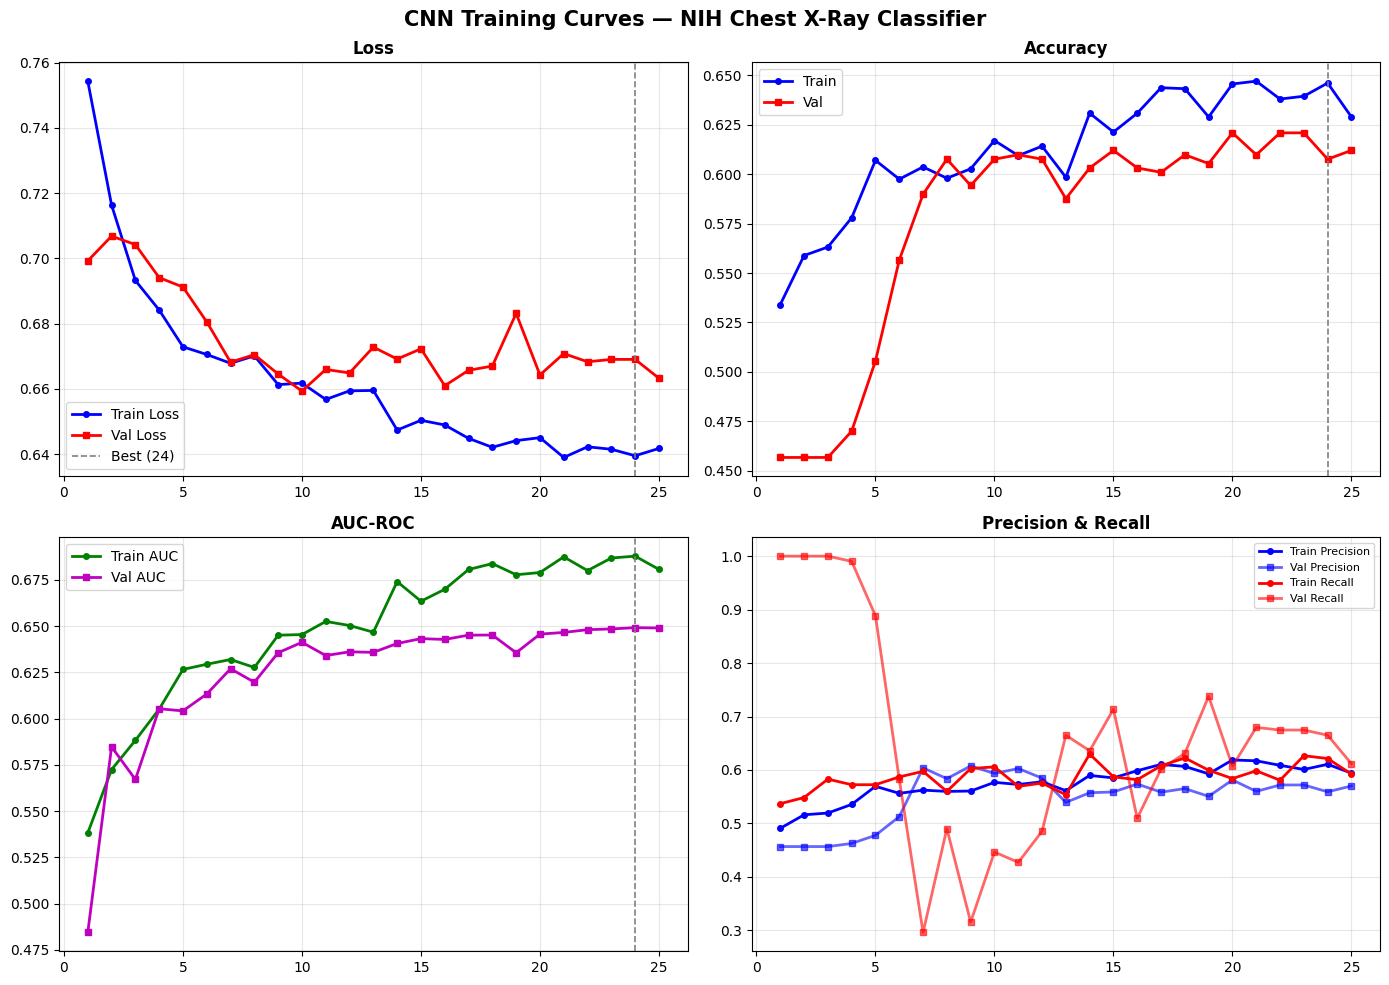

In [10]:
h = history.history; ep = range(1, len(h['loss'])+1)
best_ep = np.argmax(h['val_auc'])+1
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('CNN Training Curves — NIH Chest X-Ray Classifier', fontsize=15, fontweight='bold')
axes[0,0].plot(ep, h['loss'], 'b-o', lw=2, ms=4, label='Train Loss')
axes[0,0].plot(ep, h['val_loss'], 'r-s', lw=2, ms=4, label='Val Loss')
axes[0,0].axvline(best_ep, color='gray', ls='--', lw=1.2, label=f'Best ({best_ep})')
axes[0,0].set_title('Loss', fontweight='bold'); axes[0,0].legend(); axes[0,0].grid(alpha=0.3)
axes[0,1].plot(ep, h['accuracy'], 'b-o', lw=2, ms=4, label='Train')
axes[0,1].plot(ep, h['val_accuracy'], 'r-s', lw=2, ms=4, label='Val')
axes[0,1].axvline(best_ep, color='gray', ls='--', lw=1.2)
axes[0,1].set_title('Accuracy', fontweight='bold'); axes[0,1].legend(); axes[0,1].grid(alpha=0.3)
axes[1,0].plot(ep, h['auc'], 'g-o', lw=2, ms=4, label='Train AUC')
axes[1,0].plot(ep, h['val_auc'], 'm-s', lw=2, ms=4, label='Val AUC')
axes[1,0].axvline(best_ep, color='gray', ls='--', lw=1.2)
axes[1,0].set_title('AUC-ROC', fontweight='bold'); axes[1,0].legend(); axes[1,0].grid(alpha=0.3)
axes[1,1].plot(ep, h['precision'], 'b-o', lw=2, ms=4, label='Train Precision')
axes[1,1].plot(ep, h['val_precision'], 'b-s', lw=2, ms=4, label='Val Precision', alpha=0.6)
axes[1,1].plot(ep, h['recall'], 'r-o', lw=2, ms=4, label='Train Recall')
axes[1,1].plot(ep, h['val_recall'], 'r-s', lw=2, ms=4, label='Val Recall', alpha=0.6)
axes[1,1].set_title('Precision & Recall', fontweight='bold'); axes[1,1].legend(fontsize=8); axes[1,1].grid(alpha=0.3)
plt.tight_layout(); plt.savefig('cnn_training_curves.png', dpi=180, bbox_inches='tight'); plt.show()

## 📊 Cell 10: CNN Evaluation on Test Set

Accuracy:0.6133 | F1:0.6201 | AUC:0.6439
              precision    recall  f1-score   support

      Normal       0.68      0.55      0.61       244
    Diseased       0.56      0.69      0.62       206

    accuracy                           0.61       450
   macro avg       0.62      0.62      0.61       450
weighted avg       0.62      0.61      0.61       450



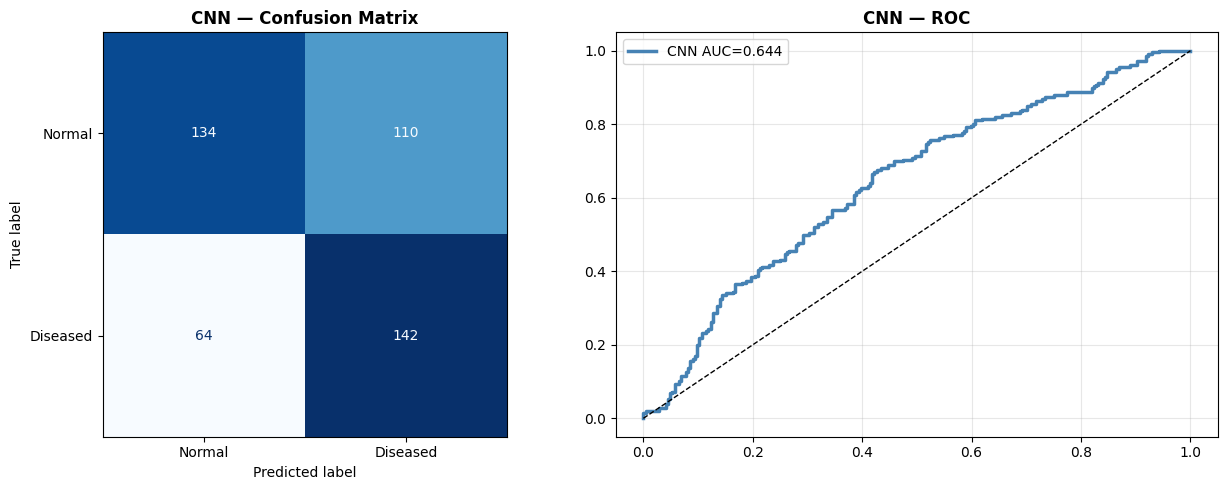

In [11]:
y_prob_cnn = cnn_model.predict(X_test, batch_size=BATCH_SIZE, verbose=0).ravel()
y_pred_cnn = (y_prob_cnn >= 0.5).astype(int)
acc_cnn = accuracy_score(y_test, y_pred_cnn)
f1_cnn  = f1_score(y_test, y_pred_cnn)
fpr_cnn, tpr_cnn, _ = roc_curve(y_test, y_prob_cnn)
roc_auc = auc(fpr_cnn, tpr_cnn)
print(f'Accuracy:{acc_cnn:.4f} | F1:{f1_cnn:.4f} | AUC:{roc_auc:.4f}')
print(classification_report(y_test, y_pred_cnn, target_names=['Normal','Diseased']))
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_cnn),
                       display_labels=['Normal','Diseased']).plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('CNN — Confusion Matrix', fontweight='bold')
axes[1].plot(fpr_cnn, tpr_cnn, color='steelblue', lw=2.5, label=f'CNN AUC={roc_auc:.3f}')
axes[1].plot([0,1],[0,1],'k--',lw=1); axes[1].set_title('CNN — ROC', fontweight='bold')
axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 🔄 Cell 11: Build & Train Autoencoder

In [12]:
def build_autoencoder(input_shape=(IMG_SIZE, IMG_SIZE, CHANNELS)):
    inp = layers.Input(shape=input_shape)
    x = layers.Conv2D(32,  3, activation='relu', padding='same')(inp)
    x = layers.MaxPooling2D(2, padding='same')(x)
    x = layers.Conv2D(64,  3, activation='relu', padding='same')(x)
    x = layers.MaxPooling2D(2, padding='same')(x)
    x = layers.Conv2D(128, 3, activation='relu', padding='same')(x)
    encoded = layers.MaxPooling2D(2, padding='same', name='Bottleneck')(x)
    x = layers.Conv2D(128, 3, activation='relu', padding='same')(encoded)
    x = layers.UpSampling2D(2)(x)
    x = layers.Conv2D(64,  3, activation='relu', padding='same')(x)
    x = layers.UpSampling2D(2)(x)
    x = layers.Conv2D(32,  3, activation='relu', padding='same')(x)
    x = layers.UpSampling2D(2)(x)
    decoded = layers.Conv2D(CHANNELS, 3, activation='sigmoid', padding='same')(x)
    autoencoder = models.Model(inp, decoded, name='ChestXray_AE')
    encoder     = models.Model(inp, encoded, name='Encoder')
    return autoencoder, encoder

autoencoder, encoder = build_autoencoder()

X_train_normal = X_train[y_train==0]; X_val_normal = X_val[y_val==0]
print(f'Normal train:{len(X_train_normal):,} | Normal val:{len(X_val_normal):,}')
autoencoder.compile(optimizer=optimizers.Adam(1e-4), loss='mse')
ae_history = autoencoder.fit(
    X_train_normal, X_train_normal,
    validation_data=(X_val_normal, X_val_normal),
    epochs=EPOCHS_AE, batch_size=BATCH_SIZE,
    callbacks=[callbacks.EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True, verbose=1)],
    verbose=1)

Normal train:1,140 | Normal val:245
Epoch 1/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 15s 360ms/step - loss: 0.0497 - val_loss: 0.0271
Epoch 2/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 13s 350ms/step - loss: 0.0150 - val_loss: 0.0102
Epoch 3/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 12s 347ms/step - loss: 0.0082 - val_loss: 0.0068
Epoch 4/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 12s 345ms/step - loss: 0.0063 - val_loss: 0.0054
Epoch 5/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 12s 347ms/step - loss: 0.0053 - val_loss: 0.0046
Epoch 6/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 13s 352ms/step - loss: 0.0046 - val_loss: 0.0042
Epoch 7/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 12s 344ms/step - loss: 0.0041 - val_loss: 0.0041
Epoch 8/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 13s 347ms/step - loss: 0.0039 - val_loss: 0.0036
Epoch 9/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 12s 344ms/step - loss: 0.0035 - val_loss: 0.0034
Epoch 10/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 12s 346ms/step - loss: 0.0033 - val_loss: 0.0030
Epoch 11/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 13s 354ms/step - loss: 0.0031 - val_loss: 0.0029
Epoch

## 🔄 Cell 12: Autoencoder Reconstruction & Anomaly Detection

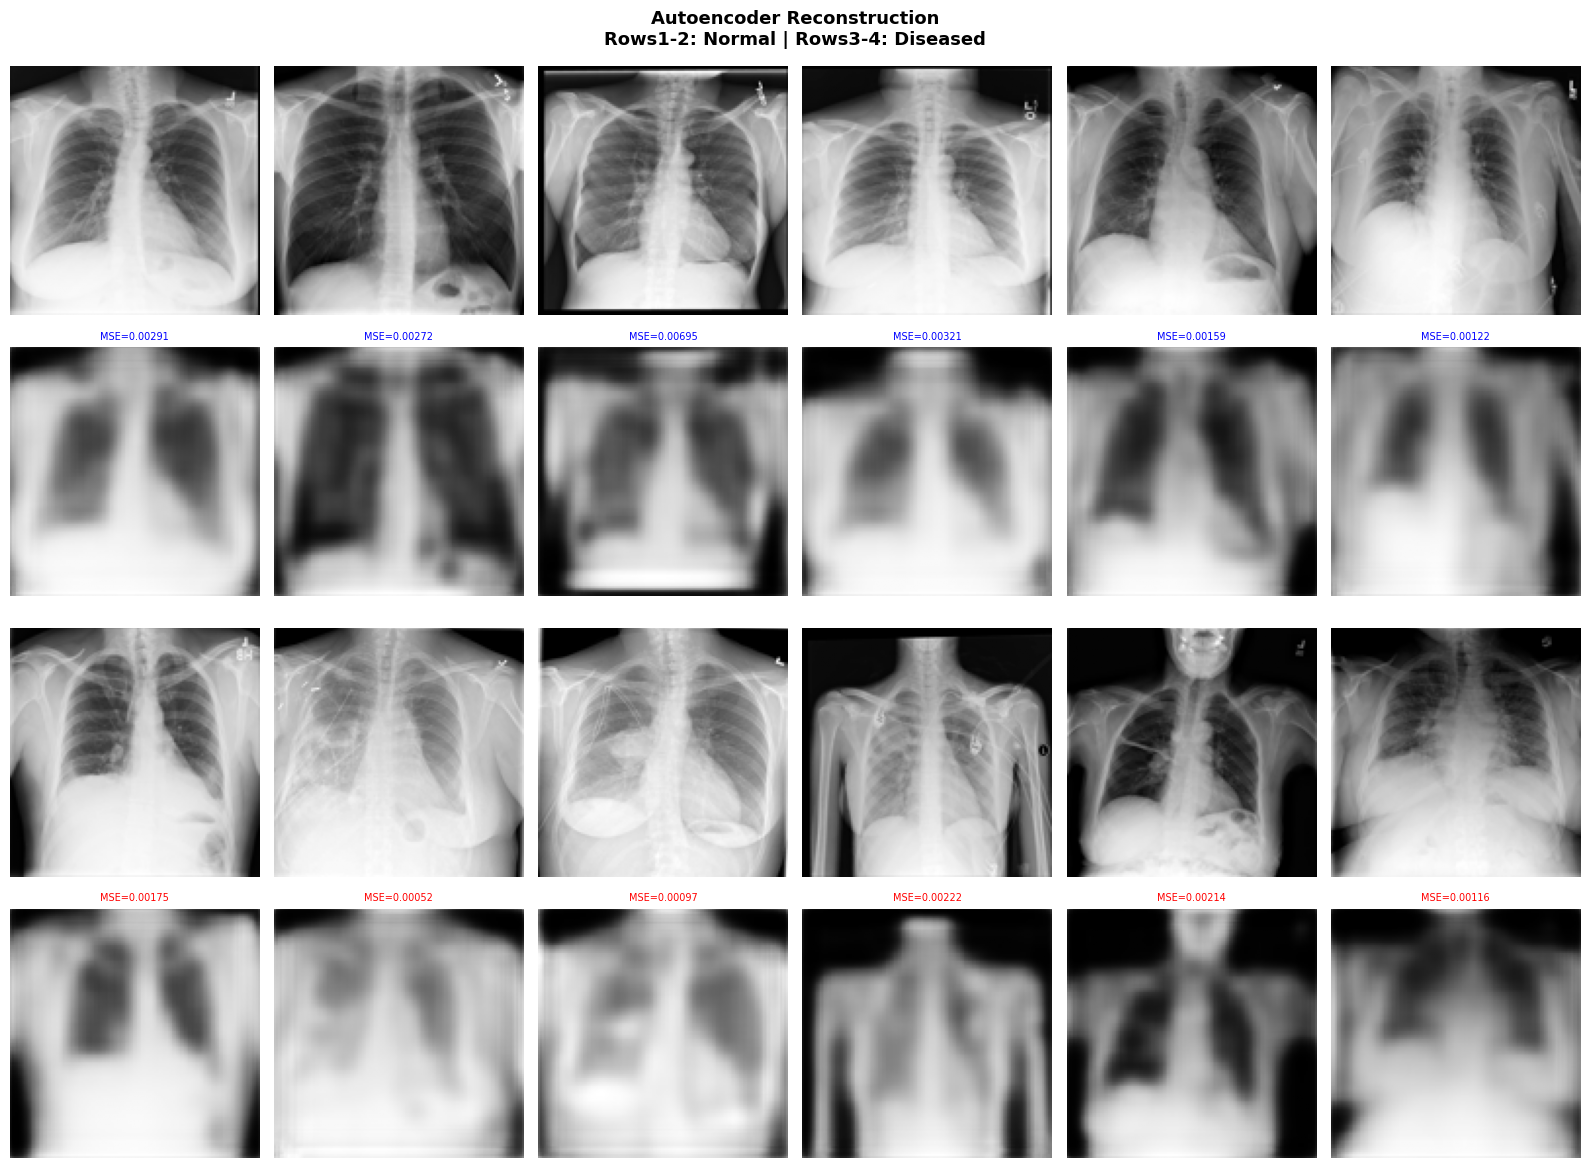

Avg MSE Normal:0.003101 | Avg MSE Diseased:0.001458
AE: Acc=0.5467 | F1=0.1282 | AUC=0.4712
              precision    recall  f1-score   support

      Normal       0.55      0.95      0.69       244
    Diseased       0.54      0.07      0.13       206

    accuracy                           0.55       450
   macro avg       0.54      0.51      0.41       450
weighted avg       0.54      0.55      0.43       450



In [13]:
idx_n = np.where(y_test==0)[0][:6]; idx_d = np.where(y_test==1)[0][:6]
imgs_n = X_test[idx_n]; imgs_d = X_test[idx_d]
recon_n = autoencoder.predict(imgs_n, batch_size=32, verbose=0)
recon_d = autoencoder.predict(imgs_d, batch_size=32, verbose=0)
mse_n = [np.mean((imgs_n[i]-recon_n[i])**2) for i in range(6)]
mse_d = [np.mean((imgs_d[i]-recon_d[i])**2) for i in range(6)]

fig, axes = plt.subplots(4, 6, figsize=(16, 12))
fig.suptitle('Autoencoder Reconstruction\nRows1-2: Normal | Rows3-4: Diseased', fontsize=13, fontweight='bold')
for r,(data,label,color,mse_row) in enumerate(zip(
        [imgs_n,recon_n,imgs_d,recon_d],
        ['Original(Normal)','Reconstruction(Normal)','Original(Diseased)','Reconstruction(Diseased)'],
        ['#27AE60','#2ECC71','#E74C3C','#C0392B'],
        [None,mse_n,None,mse_d])):
    axes[r,0].set_ylabel(label, fontsize=8, color=color, fontweight='bold')
    for c in range(6):
        axes[r,c].imshow(data[c,...,0], cmap='gray')
        if mse_row: axes[r,c].set_title(f'MSE={mse_row[c]:.5f}', fontsize=7, color='blue' if r==1 else 'red')
        axes[r,c].axis('off')
plt.tight_layout(); plt.savefig('ae_reconstruction.png', dpi=150, bbox_inches='tight'); plt.show()
print(f'Avg MSE Normal:{np.mean(mse_n):.6f} | Avg MSE Diseased:{np.mean(mse_d):.6f}')

recon_test = autoencoder.predict(X_test, batch_size=BATCH_SIZE, verbose=0)
recon_err  = np.mean((X_test - recon_test)**2, axis=(1,2,3))
err_normal   = recon_err[y_test==0]; err_diseased = recon_err[y_test==1]
threshold    = np.percentile(err_normal, 95)
y_pred_ae    = (recon_err > threshold).astype(int)
acc_ae = accuracy_score(y_test, y_pred_ae)
f1_ae  = f1_score(y_test, y_pred_ae)
fpr_ae, tpr_ae, _ = roc_curve(y_test, recon_err)
roc_auc_ae = auc(fpr_ae, tpr_ae)
print(f'AE: Acc={acc_ae:.4f} | F1={f1_ae:.4f} | AUC={roc_auc_ae:.4f}')
print(classification_report(y_test, y_pred_ae, target_names=['Normal','Diseased']))

## 🔁 Cell 13: Transfer Learning — Load RGB Data

In [14]:
TL_SIZE = 128
print('Loading RGB images for Transfer Learning...')
X_train_rgb, _ = load_images(train_df, TL_SIZE, channels=3)
X_val_rgb,   _ = load_images(val_df,   TL_SIZE, channels=3)
X_test_rgb,  _ = load_images(test_df,  TL_SIZE, channels=3)
print(f'X_train_rgb:{X_train_rgb.shape} | X_val_rgb:{X_val_rgb.shape} | X_test_rgb:{X_test_rgb.shape}')

Loading RGB images for Transfer Learning...
X_train_rgb:(2099, 128, 128, 3) | X_val_rgb:(451, 128, 128, 3) | X_test_rgb:(450, 128, 128, 3)


## 🔁 Cell 14: Transfer Learning — Train All Models

In [15]:
def build_tl_model(base_model):
    base_model.trainable = False
    inp = layers.Input(shape=(TL_SIZE, TL_SIZE, 3))
    x   = base_model(inp, training=False)
    x   = layers.GlobalAveragePooling2D()(x)
    x   = layers.Dense(256, activation='relu')(x)
    x   = layers.Dropout(0.4)(x)
    out = layers.Dense(1, activation='sigmoid')(x)
    model = models.Model(inp, out)
    model.compile(optimizer=optimizers.Adam(1e-4), loss='binary_crossentropy',
                  metrics=['accuracy', tf.keras.metrics.AUC(name='auc')])
    return model

tl_models_config = {
    'VGG16':         VGG16(weights='imagenet',         include_top=False, input_shape=(TL_SIZE,TL_SIZE,3)),
    'MobileNetV2':   MobileNetV2(weights='imagenet',   include_top=False, input_shape=(TL_SIZE,TL_SIZE,3)),
    'ResNet50':      ResNet50(weights='imagenet',       include_top=False, input_shape=(TL_SIZE,TL_SIZE,3)),
    'EfficientNetB0':EfficientNetB0(weights='imagenet', include_top=False, input_shape=(TL_SIZE,TL_SIZE,3)),
}

tl_results = {}; tl_histories = {}

for name, base in tl_models_config.items():
    print(f'\n{"="*50}\nTraining {name}...\n{"="*50}')
    model = build_tl_model(base)
    cb = [callbacks.EarlyStopping(monitor='val_auc', patience=4, restore_best_weights=True, mode='max', verbose=0),
          callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-7, verbose=0)]
    hist_frozen = model.fit(X_train_rgb, y_train, validation_data=(X_val_rgb, y_val),
                            epochs=EPOCHS_TL, batch_size=BATCH_SIZE,
                            class_weight=class_weight_dict, callbacks=cb, verbose=1)
    acc_frozen = hist_frozen.history['val_accuracy'][-1]
    auc_frozen = hist_frozen.history['val_auc'][-1]
    base.trainable = True
    for layer in base.layers[:-20]: layer.trainable = False
    model.compile(optimizer=optimizers.Adam(1e-5), loss='binary_crossentropy',
                  metrics=['accuracy', tf.keras.metrics.AUC(name='auc')])
    hist_ft = model.fit(X_train_rgb, y_train, validation_data=(X_val_rgb, y_val),
                        epochs=5, batch_size=BATCH_SIZE,
                        class_weight=class_weight_dict, callbacks=cb, verbose=1)
    y_prob_tl = model.predict(X_test_rgb, batch_size=BATCH_SIZE, verbose=0).ravel()
    y_pred_tl = (y_prob_tl >= 0.5).astype(int)
    fpr_tl, tpr_tl, _ = roc_curve(y_test, y_prob_tl)
    tl_results[name] = {
        'acc_frozen': round(acc_frozen,4), 'auc_frozen': round(auc_frozen,4),
        'acc_ft':     round(hist_ft.history['val_accuracy'][-1],4),
        'auc_ft':     round(hist_ft.history['val_auc'][-1],4),
        'test_acc':   round(accuracy_score(y_test, y_pred_tl),4),
        'test_f1':    round(f1_score(y_test, y_pred_tl),4),
        'test_auc':   round(auc(fpr_tl, tpr_tl),4),
    }
    tl_histories[name] = (hist_frozen, hist_ft)
    print(f'{name} done -> Test Acc={tl_results[name]["test_acc"]}')

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 24s 0us/step
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step

Training VGG16...
Epoch 1/8
66/66 ━━━━━━━━━━━━━━━━━━━━ 74s 1s/step - accuracy: 0.5303 - auc: 0.5403 - loss: 0.7011 - val_accuracy: 0.5898 - val_auc: 0.6505 - val_loss: 0.6800 - learning_rate: 1.0000e-04
Epoch 2/8
66/66 ━━━━━━━━━━━━━━━━━━━━ 73s 1s/step - accuracy: 0.5431 - auc: 0.5607 - loss: 0.6919 - val_accuracy: 0.6098 - val_auc: 0.6583 - val_loss: 0.6716 - learning_rate: 1.0000e-04
Epoch 3/8
66/66 ━━━━━━━━━━━━━━━━━━━━ 72s 1s/step - accuracy: 0.5646 - auc: 0.5877 - loss: 0.6835 - val_accuracy: 0.6075 - val_auc: 0.6623 - val_loss: 0.6671 - learning_rate: 1.0000e-04
Epoch 4/8
66/66 ━━━━━━━━━━━━━━━━━━━━ 72s 1s/step - accuracy: 0.5846 - auc: 0.6081 - loss: 0.6760 - val_accuracy: 0.6075 - val_auc: 0.6652 - val_loss: 0.6610 - learning_rate: 1.0000e-04
Epoch 5/8
66/66 ━━━━━━━━━━━━━━━━━━━━ 74s 1s/step - accuracy: 0.5803 - auc: 0.6135 - loss:

## 🔁 Cell 15: Transfer Learning — Comparison Table

TRANSFER LEARNING COMPARISON TABLE


,Model,Val Acc (Frozen),Val AUC (Frozen),Val Acc (Fine-Tuned),Val AUC (Fine-Tuned),Test Accuracy,Test F1,Test AUC
0,VGG16,0.6319,0.6736,0.6696,0.7168,0.6667,0.6544,0.7048
1,MobileNetV2,0.6608,0.6951,0.6452,0.6935,0.6244,0.5292,0.6651
2,ResNet50,0.4723,0.5924,0.5432,0.5724,0.4822,0.6199,0.5539
3,EfficientNetB0,0.4568,0.5000,0.5432,0.4951,0.4600,0.6267,0.5001


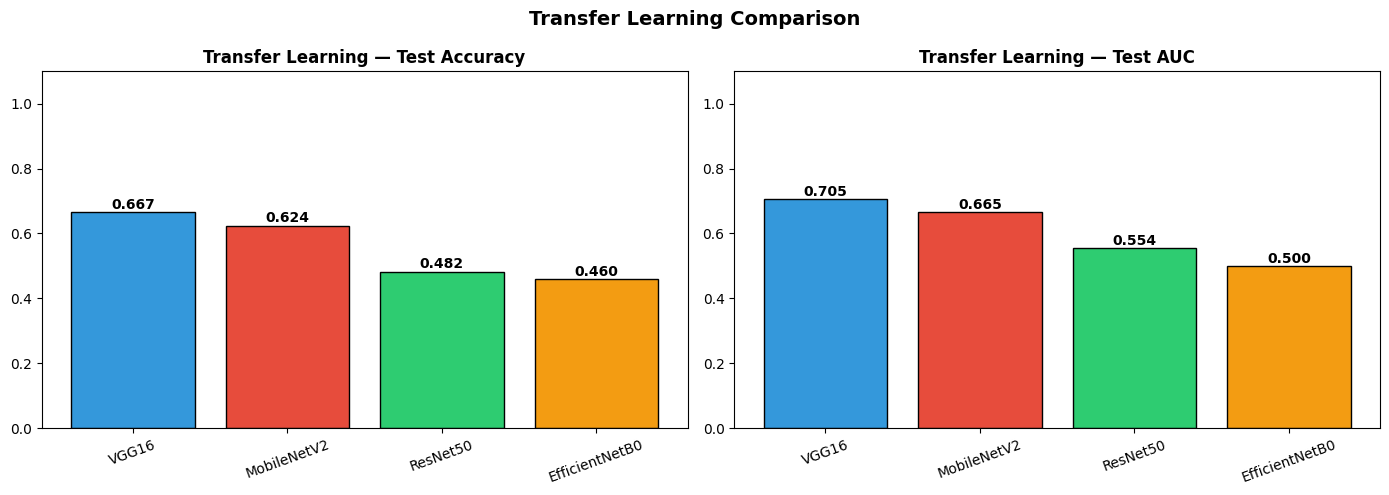

In [16]:
tl_df = pd.DataFrame([{'Model':name, 'Val Acc (Frozen)':v['acc_frozen'],
                        'Val AUC (Frozen)':v['auc_frozen'], 'Val Acc (Fine-Tuned)':v['acc_ft'],
                        'Val AUC (Fine-Tuned)':v['auc_ft'], 'Test Accuracy':v['test_acc'],
                        'Test F1':v['test_f1'], 'Test AUC':v['test_auc']}
                       for name,v in tl_results.items()])
print('='*80); print('TRANSFER LEARNING COMPARISON TABLE'); print('='*80)
display(tl_df)

names = list(tl_results.keys())
colors = ['#3498DB','#E74C3C','#2ECC71','#F39C12']
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
test_accs = [tl_results[n]['test_acc'] for n in names]
test_aucs = [tl_results[n]['test_auc'] for n in names]
axes[0].bar(names, test_accs, color=colors, edgecolor='black')
axes[0].set_title('Transfer Learning — Test Accuracy', fontweight='bold')
axes[0].set_ylim(0,1.1); axes[0].tick_params(axis='x', rotation=20)
for i,v in enumerate(test_accs): axes[0].text(i, v+0.01, f'{v:.3f}', ha='center', fontweight='bold')
axes[1].bar(names, test_aucs, color=colors, edgecolor='black')
axes[1].set_title('Transfer Learning — Test AUC', fontweight='bold')
axes[1].set_ylim(0,1.1); axes[1].tick_params(axis='x', rotation=20)
for i,v in enumerate(test_aucs): axes[1].text(i, v+0.01, f'{v:.3f}', ha='center', fontweight='bold')
plt.suptitle('Transfer Learning Comparison', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.savefig('transfer_learning_comparison.png', dpi=180, bbox_inches='tight'); plt.show()

## ⚡ Cell 16: Optimizer Comparison — Adam vs SGD vs RMSprop

In [17]:
def build_simple_cnn(input_shape=(IMG_SIZE, IMG_SIZE, CHANNELS)):
    inp = layers.Input(shape=input_shape)
    x = layers.Conv2D(32,  3, activation='relu', padding='same')(inp)
    x = layers.BatchNormalization()(x); x = layers.MaxPooling2D(2)(x)
    x = layers.Conv2D(64,  3, activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x); x = layers.MaxPooling2D(2)(x)
    x = layers.Conv2D(128, 3, activation='relu', padding='same')(x)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(128, activation='relu')(x); x = layers.Dropout(0.4)(x)
    out = layers.Dense(1, activation='sigmoid')(x)
    return models.Model(inp, out)

optimizers_config = {
    'Adam':    optimizers.Adam(learning_rate=1e-4),
    'SGD':     optimizers.SGD(learning_rate=1e-3, momentum=0.9),
    'RMSprop': optimizers.RMSprop(learning_rate=1e-4),
}

opt_histories = {}; opt_results = {}

for opt_name, opt in optimizers_config.items():
    print(f'\nTraining with {opt_name}...')
    model = build_simple_cnn()
    model.compile(optimizer=opt, loss='binary_crossentropy',
                  metrics=['accuracy', tf.keras.metrics.AUC(name='auc')])
    hist = model.fit(X_train, y_train, validation_data=(X_val, y_val),
                     epochs=EPOCHS_OPT, batch_size=BATCH_SIZE,
                     class_weight=class_weight_dict, verbose=1)
    y_prob = model.predict(X_test, batch_size=BATCH_SIZE, verbose=0).ravel()
    y_pred = (y_prob >= 0.5).astype(int)
    fpr_o, tpr_o, _ = roc_curve(y_test, y_prob)
    opt_histories[opt_name] = hist
    opt_results[opt_name] = {
        'test_acc': round(accuracy_score(y_test, y_pred),4),
        'test_f1':  round(f1_score(y_test, y_pred),4),
        'test_auc': round(auc(fpr_o, tpr_o),4),
        'val_acc':  round(max(hist.history['val_accuracy']),4),
        'val_auc':  round(max(hist.history['val_auc']),4),
    }
    print(f'{opt_name} done -> Test Acc={opt_results[opt_name]["test_acc"]}')


Training with Adam...
Epoch 1/8
66/66 ━━━━━━━━━━━━━━━━━━━━ 24s 341ms/step - accuracy: 0.5164 - auc: 0.5356 - loss: 0.6981 - val_accuracy: 0.5011 - val_auc: 0.5457 - val_loss: 0.6932
Epoch 2/8
66/66 ━━━━━━━━━━━━━━━━━━━━ 23s 345ms/step - accuracy: 0.5426 - auc: 0.5655 - loss: 0.6888 - val_accuracy: 0.4900 - val_auc: 0.5845 - val_loss: 0.6935
Epoch 3/8
66/66 ━━━━━━━━━━━━━━━━━━━━ 23s 347ms/step - accuracy: 0.5479 - auc: 0.5722 - loss: 0.6862 - val_accuracy: 0.5166 - val_auc: 0.5804 - val_loss: 0.6924
Epoch 4/8
66/66 ━━━━━━━━━━━━━━━━━━━━ 22s 333ms/step - accuracy: 0.5693 - auc: 0.5926 - loss: 0.6805 - val_accuracy: 0.5366 - val_auc: 0.5833 - val_loss: 0.6895
Epoch 5/8
66/66 ━━━━━━━━━━━━━━━━━━━━ 22s 333ms/step - accuracy: 0.5626 - auc: 0.5807 - loss: 0.6854 - val_accuracy: 0.5344 - val_auc: 0.5828 - val_loss: 0.6904
Epoch 6/8
66/66 ━━━━━━━━━━━━━━━━━━━━ 23s 345ms/step - accuracy: 0.5679 - auc: 0.5943 - loss: 0.6799 - val_accuracy: 0.5610 - val_auc: 0.5948 - val_loss: 0.6847
Epoch 7/8
66/66 ━

## ⚡ Cell 17: Optimizer Comparison — Plots & Table

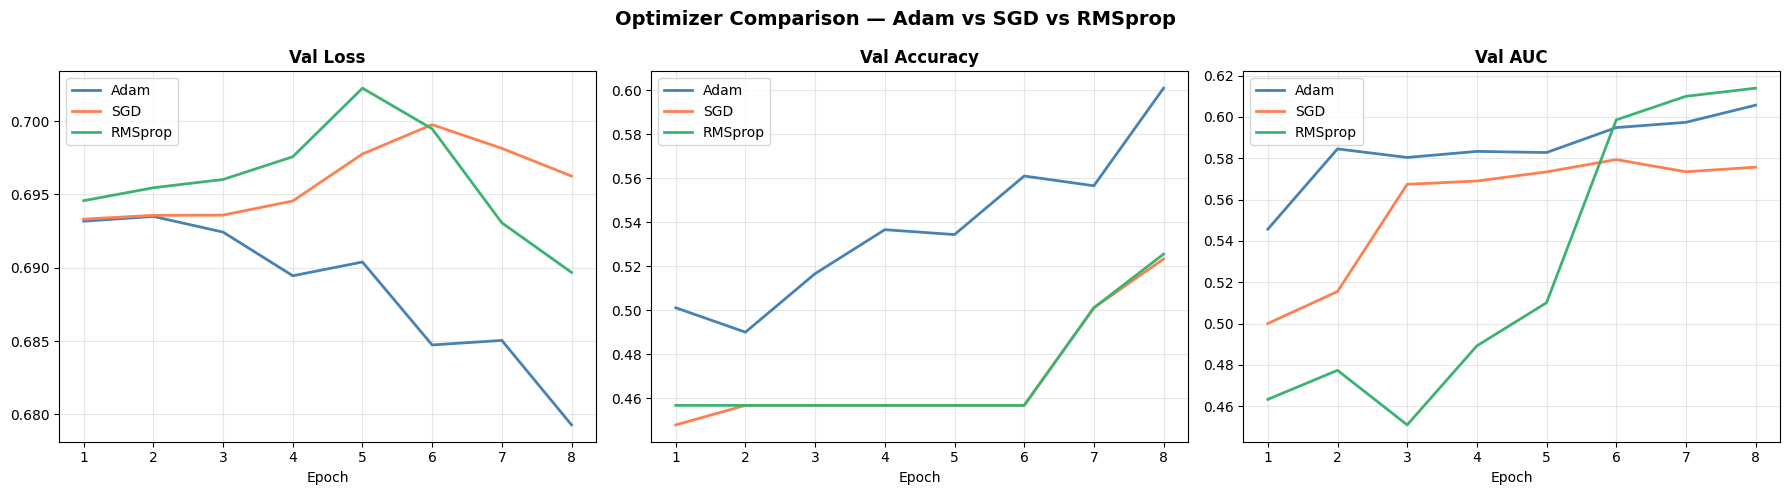

OPTIMIZER COMPARISON TABLE


,Optimizer,Best Val Acc,Best Val AUC,Test Accuracy,Test F1,Test AUC
0,Adam,0.6009,0.6057,0.5422,0.4951,0.5748
1,SGD,0.5233,0.5793,0.4978,0.6182,0.5357
2,RMSprop,0.5255,0.6139,0.5022,0.6014,0.5806


In [18]:
opt_colors = {'Adam':'steelblue', 'SGD':'coral', 'RMSprop':'mediumseagreen'}
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for opt_name, hist in opt_histories.items():
    ep = range(1, len(hist.history['loss'])+1); color = opt_colors[opt_name]
    axes[0].plot(ep, hist.history['val_loss'],     color=color, lw=2, label=opt_name)
    axes[1].plot(ep, hist.history['val_accuracy'], color=color, lw=2, label=opt_name)
    axes[2].plot(ep, hist.history['val_auc'],      color=color, lw=2, label=opt_name)
axes[0].set_title('Val Loss',     fontweight='bold'); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].set_title('Val Accuracy', fontweight='bold'); axes[1].legend(); axes[1].grid(alpha=0.3)
axes[2].set_title('Val AUC',      fontweight='bold'); axes[2].legend(); axes[2].grid(alpha=0.3)
for ax in axes: ax.set_xlabel('Epoch')
plt.suptitle('Optimizer Comparison — Adam vs SGD vs RMSprop', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.savefig('optimizer_comparison.png', dpi=180, bbox_inches='tight'); plt.show()

opt_df = pd.DataFrame([{'Optimizer':name, 'Best Val Acc':v['val_acc'], 'Best Val AUC':v['val_auc'],
                         'Test Accuracy':v['test_acc'], 'Test F1':v['test_f1'], 'Test AUC':v['test_auc']}
                        for name,v in opt_results.items()])
print('='*65); print('OPTIMIZER COMPARISON TABLE'); print('='*65)
display(opt_df)

## 🏆 Cell 18: Final Phase 2 Comparison Table

PHASE 2 — FINAL RESULTS COMPARISON


,Model,Accuracy,F1-Score,AUC-ROC
0,CNN (scratch),0.613333,0.620087,0.643920
1,Autoencoder,0.546667,0.128205,0.471232
2,TL:VGG16,0.666700,0.654400,0.704800
3,TL:MobileNetV2,0.624400,0.529200,0.665100
4,TL:ResNet50,0.482200,0.619900,0.553900
5,TL:EfficientNetB0,0.460000,0.626700,0.500100
6,CNN+Adam,0.542200,0.495100,0.574800
7,CNN+SGD,0.497800,0.618200,0.535700
8,CNN+RMSprop,0.502200,0.601400,0.580600


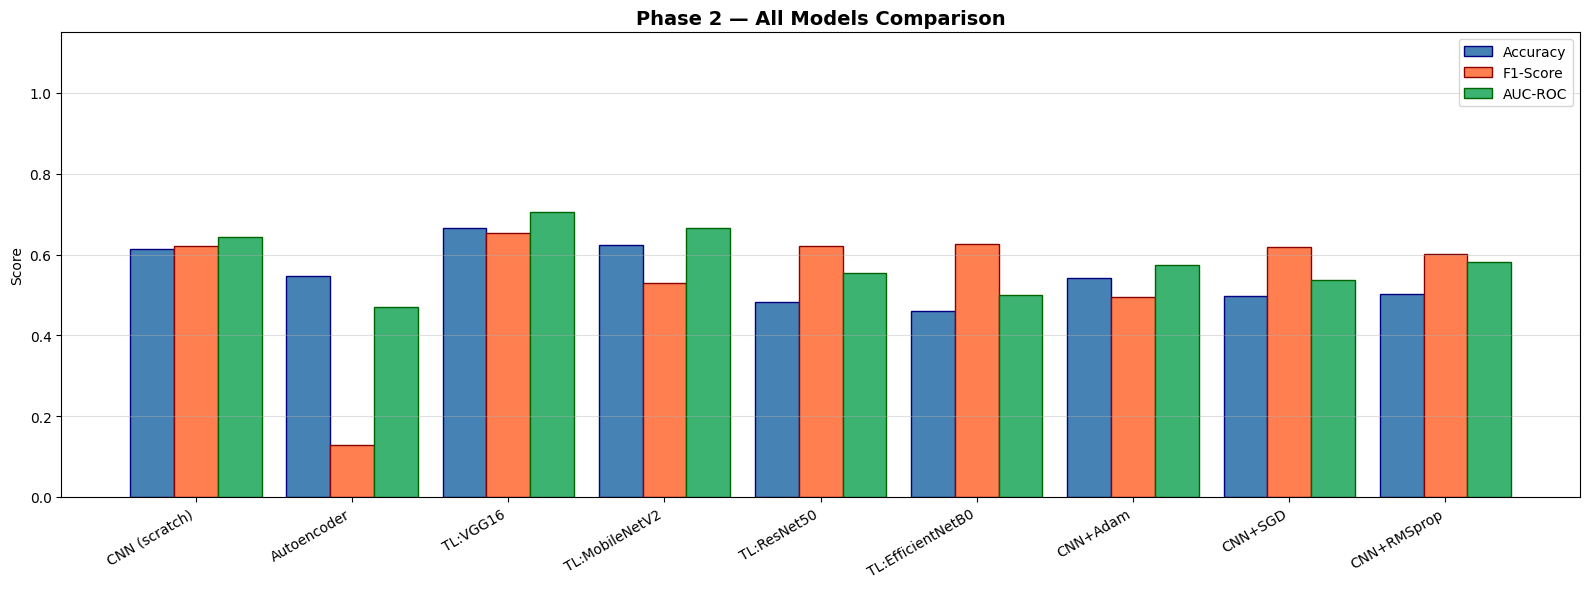


 Best model: TL:VGG16 -> Accuracy=0.6667 | AUC=0.7048


In [19]:
final_results = pd.DataFrame({
    'Model': ['CNN (scratch)', 'Autoencoder',
              'TL:VGG16', 'TL:MobileNetV2', 'TL:ResNet50', 'TL:EfficientNetB0',
              'CNN+Adam', 'CNN+SGD', 'CNN+RMSprop'],
    'Accuracy': [acc_cnn, acc_ae,
                 tl_results['VGG16']['test_acc'], tl_results['MobileNetV2']['test_acc'],
                 tl_results['ResNet50']['test_acc'], tl_results['EfficientNetB0']['test_acc'],
                 opt_results['Adam']['test_acc'], opt_results['SGD']['test_acc'],
                 opt_results['RMSprop']['test_acc']],
    'F1-Score': [f1_cnn, f1_ae,
                 tl_results['VGG16']['test_f1'], tl_results['MobileNetV2']['test_f1'],
                 tl_results['ResNet50']['test_f1'], tl_results['EfficientNetB0']['test_f1'],
                 opt_results['Adam']['test_f1'], opt_results['SGD']['test_f1'],
                 opt_results['RMSprop']['test_f1']],
    'AUC-ROC':  [roc_auc, roc_auc_ae,
                 tl_results['VGG16']['test_auc'], tl_results['MobileNetV2']['test_auc'],
                 tl_results['ResNet50']['test_auc'], tl_results['EfficientNetB0']['test_auc'],
                 opt_results['Adam']['test_auc'], opt_results['SGD']['test_auc'],
                 opt_results['RMSprop']['test_auc']]
})

print('='*70); print('PHASE 2 — FINAL RESULTS COMPARISON'); print('='*70)
display(final_results)

fig, ax = plt.subplots(figsize=(16, 6))
x = np.arange(len(final_results)); w = 0.28
ax.bar(x-w, final_results['Accuracy'], w, label='Accuracy',  color='steelblue',      edgecolor='navy')
ax.bar(x,   final_results['F1-Score'], w, label='F1-Score',  color='coral',           edgecolor='darkred')
ax.bar(x+w, final_results['AUC-ROC'], w, label='AUC-ROC',   color='mediumseagreen',  edgecolor='darkgreen')
ax.set_xticks(x); ax.set_xticklabels(final_results['Model'], rotation=30, ha='right')
ax.set_ylim(0,1.15); ax.set_ylabel('Score')
ax.set_title('Phase 2 — All Models Comparison', fontsize=14, fontweight='bold')
ax.legend(); ax.grid(True, axis='y', alpha=0.4)
plt.tight_layout(); plt.savefig('phase2_final_comparison.png', dpi=180, bbox_inches='tight'); plt.show()

best = final_results.loc[final_results['Accuracy'].idxmax()]
print(f'\n Best model: {best["Model"]} -> Accuracy={best["Accuracy"]:.4f} | AUC={best["AUC-ROC"]:.4f}')
